In [1]:
!pip install -q kagglehub

import kagglehub

# Download the dataset
path = kagglehub.dataset_download("salader/dogsvscats")

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Dataset downloaded to: /kaggle/input/dogsvscats


In [4]:
import os

print(os.listdir(path))

['test', 'train', 'catsvsdogs']


In [5]:
train_path = os.path.join(path, "train")
test_path = os.path.join(path, "test")

print(train_path)
print(test_path)

/kaggle/input/dogsvscats/train
/kaggle/input/dogsvscats/test


In [9]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
import matplotlib.pyplot as plt
import cv2

# Load the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    directory="/kaggle/input/dogsvscats/train",
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)
# Load the validation dataset
validation_ds = tf.keras.utils.image_dataset_from_directory(
    directory="/kaggle/input/dogsvscats/test",
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)
# ==========================================
# 3. DATA PREPROCESSING (NORMALIZATION)
# ==========================================
# Normalize pixel values from [0, 255] to [0, 1]
def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [10]:
# ==========================================
# 4. CNN MODEL ARCHITECTURE
# ==========================================
model = Sequential()

# 1st Convolutional Block
model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# 2nd Convolutional Block
model.add(Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# 3rd Convolutional Block
model.add(Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# Flattening and Fully Connected Layers
model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))

# Output Layer for Binary Classification
model.add(Dense(1, activation='sigmoid'))

model.summary()

# ==========================================
# 5. MODEL COMPILATION & TRAINING
# ==========================================
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Execute training across 10 epochs
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 134ms/step - accuracy: 0.5768 - loss: 1.8499 - val_accuracy: 0.6474 - val_loss: 0.6364
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 92ms/step - accuracy: 0.6944 - loss: 0.5812 - val_accuracy: 0.7058 - val_loss: 0.6058
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 97ms/step - accuracy: 0.7531 - loss: 0.5088 - val_accuracy: 0.7556 - val_loss: 0.5107
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.7946 - loss: 0.4414 - val_accuracy: 0.7238 - val_loss: 0.5645
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.8253 - loss: 0.3878 - val_accuracy: 0.8110 - val_loss: 0.4105
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.8652 - loss: 0.3144 - val_accuracy: 0.7816 - val_loss: 0.4636
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.9024 - loss: 0.2373 - val_accuracy: 0.8014 - val_loss: 0.4185
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.9362 - loss: 0.1639 -

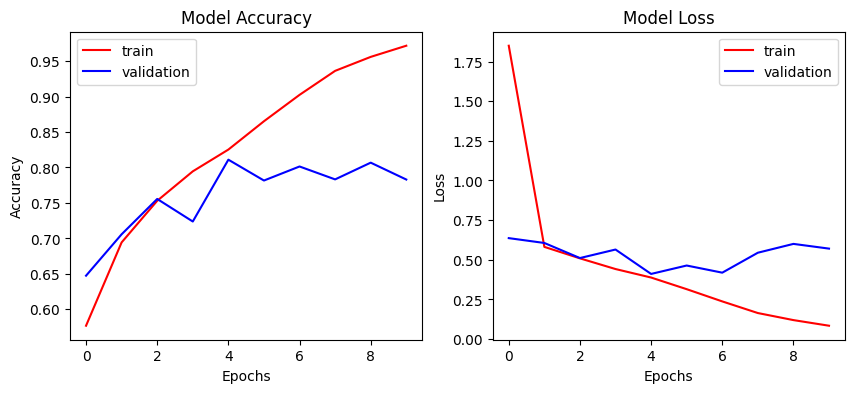

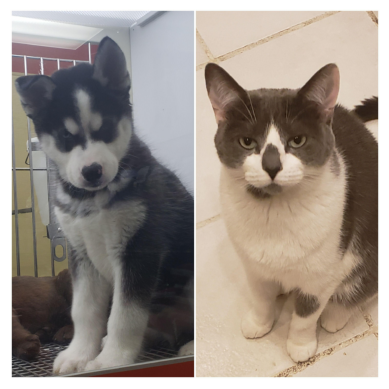

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Raw Prediction Value: 0.6556955575942993
Prediction: It's a DOG!


In [13]:
# ==========================================
# 6. EVALUATION (LOSS & ACCURACY PLOTS)
# ==========================================
# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# ==========================================
# 7. INFERENCE (PREDICTING ON NEW IMAGES)
# ==========================================
# Replace path with your actual test image path (e.g., 'cat.jpg' or 'dog.jpg')
image_path = '/content/fun.jpg'

if os.path.exists(image_path):
    test_img = cv2.imread(image_path)
    # Convert BGR (OpenCV default) to RGB for correct matplotlib plotting
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.show()

    # Preprocess the image to fit model expectations
    test_img_resized = cv2.resize(test_img, (256, 256))
    test_input = test_img_resized.reshape((1, 256, 256, 3))

    # Scale image pixels if the training pipeline scales them
    test_input = test_input / 255.0

    # Prediction
    prediction = model.predict(test_input)
    print(f"Raw Prediction Value: {prediction[0][0]}")

    if prediction[0][0] < 0.5:
        print("Prediction: It's a CAT!")
    else:
        print("Prediction: It's a DOG!")
else:
    print(f"Image not found at {image_path}. Please check your path.")